In [1]:
import pandas as pd
import joblib
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load test set
df = pd.read_csv('res_parsed/test.csv')
features = ['mean_h', 'mean_s', 'mean_v', 'std_h', 'std_s', 'std_v']
X_test = df[features]
y_true = df['label']

# Load models and label encoder
rf_model = joblib.load('model/random_forest_color_classifier.pkl')
xgb_model = joblib.load('model/xgboost_color_classifier.pkl')
label_encoder = joblib.load('model/label_encoder.pkl')
y_true_enc = label_encoder.transform(y_true)

# --- Hard Voting ---
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# Hard voting: majority class
ensemble_hard = []
for i in range(len(X_test)):
    votes = [rf_pred[i], xgb_pred[i]]
    ensemble_hard.append(max(set(votes), key=votes.count))

print(" Hard Voting Accuracy:", accuracy_score(y_true_enc, ensemble_hard))
print(classification_report(y_true_enc, ensemble_hard, target_names=label_encoder.classes_))

# --- Soft Voting (if models support predict_proba) ---
rf_proba = rf_model.predict_proba(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

# Average probabilities
ensemble_proba = (rf_proba + xgb_proba) / 2
ensemble_soft = np.argmax(ensemble_proba, axis=1)

print("\n Soft Voting Accuracy:", accuracy_score(y_true_enc, ensemble_soft))
print(classification_report(y_true_enc, ensemble_soft, target_names=label_encoder.classes_))


 Hard Voting Accuracy: 0.8045977011494253
              precision    recall  f1-score   support

      Autumn       0.89      0.71      0.79        45
      Spring       0.73      0.89      0.80        45
      Summer       0.87      0.87      0.87        45
      Winter       0.76      0.74      0.75        39

    accuracy                           0.80       174
   macro avg       0.81      0.80      0.80       174
weighted avg       0.81      0.80      0.80       174


 Soft Voting Accuracy: 0.7873563218390804
              precision    recall  f1-score   support

      Autumn       0.89      0.71      0.79        45
      Spring       0.72      0.84      0.78        45
      Summer       0.86      0.84      0.85        45
      Winter       0.71      0.74      0.72        39

    accuracy                           0.79       174
   macro avg       0.79      0.79      0.79       174
weighted avg       0.80      0.79      0.79       174



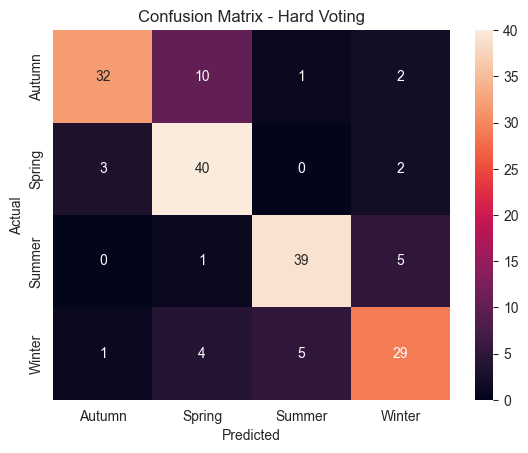

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true_enc, ensemble_hard)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Hard Voting")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [3]:
import numpy as np
import cv2
from PIL import Image
import torch
import torchvision.transforms as transforms
from model import BiSeNet  # your BiSeNet model
from ensemble_classifier import EnsembleColorClassifier


In [4]:
def extract_skin_hsv_features(image_path, model_path='res/cp/79999_iter.pth'):
    # Load and preprocess image
    img = Image.open(image_path).convert('RGB').resize((512, 512), Image.BILINEAR)
    image_np = np.array(img)

    # Prepare BiSeNet
    net = BiSeNet(n_classes=19)
    net.cuda()
    net.load_state_dict(torch.load(model_path))
    net.eval()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
    ])
    input_tensor = transform(img).unsqueeze(0).cuda()

    # Run segmentation
    with torch.no_grad():
        out = net(input_tensor)[0]
    parsing = out.squeeze(0).cpu().numpy().argmax(0)

    # Resize mask to image size
    parsing = cv2.resize(parsing.astype(np.uint8), img.size, interpolation=cv2.INTER_NEAREST)
    skin_mask = (parsing == 1).astype(np.uint8) * 255

    # Apply mask
    skin_rgb = cv2.bitwise_and(image_np, image_np, mask=skin_mask)
    skin_hsv = cv2.cvtColor(skin_rgb, cv2.COLOR_RGB2HSV)

    # Filter out black (non-skin)
    mask = skin_hsv[:, :, 1] > 0
    h = skin_hsv[:, :, 0][mask]
    s = skin_hsv[:, :, 1][mask]
    v = skin_hsv[:, :, 2][mask]

    if len(h) == 0:
        raise ValueError("No skin detected.")

    return np.array([np.mean(h), np.mean(s), np.mean(v), np.std(h), np.std(s), np.std(v)]).reshape(1, -1)


In [14]:
# Load the ensemble model
ensemble = EnsembleColorClassifier(
    rf_path='model/random_forest_color_classifier.pkl',
    xgb_path='model/xgboost_color_classifier.pkl',
    encoder_path='model/label_encoder.pkl',
    mode='hard'  # or 'soft'
)

image_path = 'dataset_fake/Winter/seed0130.png'

# Extract features
features = extract_skin_hsv_features(image_path)

# Predict
predicted_season = ensemble.predict(features)[0]
print("Predicted Personal Color Season:", predicted_season)

Predicted Personal Color Season: Winter


D:\001_MLProjects\color_analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
